# Outlier Removal Using Z-Score

### What is an Outlier?
An outlier is a value that is **very different from the rest of the data**.

```
Normal CGPA values: 6.5, 7.0, 7.2, 6.8, 7.5
Outlier:            6.5, 7.0, 7.2, 6.8, 7.5, 1.0  ← 1.0 is suspicious
```

### Why remove outliers?
Outliers can mislead the model — making it learn wrong patterns.

### What is Z-Score?
Z-Score tells you **how many standard deviations a value is away from the mean**:
```
z = (value - mean) / std

z = 0   → value is exactly at the mean
z = 1   → value is 1 std above mean
z = -2  → value is 2 std below mean
z > 3   → very far from mean → likely an outlier
z < -3  → very far below mean → likely an outlier
```
The **3 standard deviation rule**: 99.7% of data falls within 3 std of mean.
Anything beyond ±3 is considered an outlier.

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the placement dataset
# Contains cgpa, placement_exam_marks and whether student got placed
df = pd.read_csv('placement.csv')

In [4]:
# Check shape — how many rows and columns
df.shape

(1000, 3)

In [5]:
# Preview 5 random rows to understand the data
df.sample(5)

,cgpa,placement_exam_marks,placed
424,6.91,30.0,0
579,7.13,13.0,0
656,7.39,72.0,1
614,8.05,41.0,0
998,8.62,46.0,1


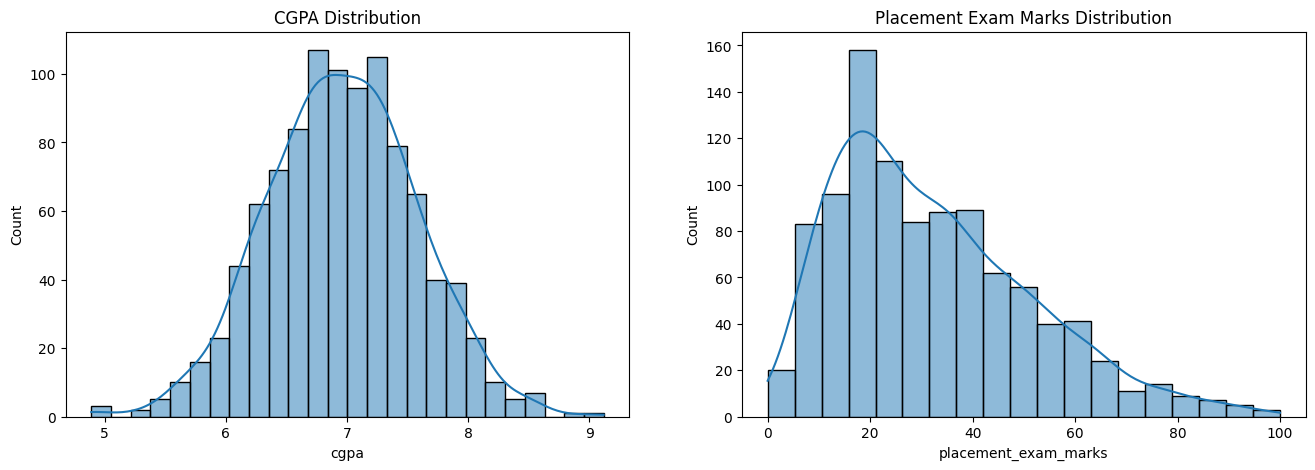

In [6]:
# Plot distribution of cgpa and placement_exam_marks
# Normal distribution = bell curve shape
# Skewed distribution = outliers pulling the tail to one side
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('CGPA Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.show()

In [7]:
# Check skewness of placement_exam_marks
# skew = 0   → perfectly normal distribution
# skew > 0   → right skewed (outliers on right/high side)
# skew < 0   → left skewed (outliers on left/low side)
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

## Approach 1 — Manual Boundary Calculation

In [8]:
# Check basic statistics of cgpa
print("Mean value of cgpa", df['cgpa'].mean())
print("Std value of cgpa",  df['cgpa'].std())
print("Min value of cgpa",  df['cgpa'].min())
print("Max value of cgpa",  df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [9]:
# Calculate boundary values using 3 standard deviation rule
# Any value outside these boundaries is an outlier
# upper = mean + 3*std → anything above this is too high
# lower = mean - 3*std → anything below this is too low
upper_boundary = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_boundary = df['cgpa'].mean() - 3 * df['cgpa'].std()

print("Highest allowed:", upper_boundary)
print("Lowest allowed: ", lower_boundary)

Highest allowed: 8.808933625397168
Lowest allowed:  5.113546374602832


In [10]:
# Find all outlier rows — values outside the boundaries
# | means OR — cgpa is either too high OR too low
df[(df['cgpa'] > upper_boundary) | (df['cgpa'] < lower_boundary)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Approach 1a — Trimming (remove outlier rows completely)

In [11]:
# Trimming — keep only rows where cgpa is within boundaries
# This REMOVES the outlier rows from the dataset entirely
# Downside: we lose data — total rows will decrease
new_df = df[(df['cgpa'] < upper_boundary) & (df['cgpa'] > lower_boundary)]

print("Original shape:", df.shape)
print("After trimming: ", new_df.shape)
new_df

Original shape: (1000, 3)
After trimming:  (995, 3)


,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


## Approach 2 — Z-Score Method

In [12]:
# Calculate Z-Score for each cgpa value
# Formula: z = (value - mean) / std
# z > 3  → outlier on high side
# z < -3 → outlier on low side
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [13]:
# Find outliers on the HIGH side (z > 3)
# These are students with unusually HIGH cgpa
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [14]:
# Find outliers on the LOW side (z < -3)
# These are students with unusually LOW cgpa
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [15]:
# Find ALL outliers — both high and low side combined
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [16]:
# Trimming using Z-Score — same result as approach 1a but cleaner syntax
# Keep only rows where z-score is between -3 and 3
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

print("Original shape:", df.shape)
print("After trimming: ", new_df.shape)
new_df

Original shape: (1000, 4)
After trimming:  (995, 4)


,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Approach 2b — Capping (replace outliers instead of removing them)

Instead of deleting outlier rows, **cap** them at the boundary value.

```
Trimming:  cgpa = 9.5 (outlier) → ROW DELETED
Capping:   cgpa = 9.5 (outlier) → replaced with 8.80 (upper boundary)
```

Advantage: no data loss — all rows are kept.

In [17]:
# Calculate upper and lower limits
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

print("Upper limit:", upper_limit)
print("Lower limit:", lower_limit)

Upper limit: 8.808933625397168
Lower limit: 5.113546374602832


In [18]:
# Apply capping using np.where
# np.where(condition, value_if_true, value_if_false)

# Logic:
# if cgpa > upper_limit → replace with upper_limit
# elif cgpa < lower_limit → replace with lower_limit
# else → keep original value

df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,                    # cap high outliers at upper limit
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,                # cap low outliers at lower limit
        df['cgpa']                  # keep original if within range
    )
)

In [19]:
# Shape stays the same — no rows were deleted
df.shape

(1000, 4)

In [20]:
# Check cgpa stats after capping
# Max should now equal upper_limit
# Min should now equal lower_limit
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

## Summary

| Method | What it does | Data Loss? |
|---|---|---|
| **Trimming** | removes outlier rows completely | Yes — row count decreases |
| **Capping** | replaces outlier values with boundary values | No — row count stays same |

### When to use which?
- **Trimming** → when you have lots of data and few outliers
- **Capping** → when you can't afford to lose rows (small dataset)

### Z-Score Rule:
```
z > 3  or z < -3 → outlier (beyond 3 standard deviations from mean)
```